# pymoo NSGA-II — Results

**MOML Assignment** — Prof. Aswin Kannan · Niranjan Gopal, Divyam Sareen · Due 2026-04-28

This notebook **only views results** — no training, no optimization. It auto-loads the latest pymoo study under `results/pymoo/<dataset>/` and walks through it cell by cell with explanations.

If you want to re-run the optimization, see `pymoo_optimization.ipynb` (lite) or `pymoo_optimization_full.ipynb` (heavy GPU).

In [1]:
# --- Imports & path setup -------------------------------------------------
import sys, json
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import pandas as pd
from IPython.display import Image, display, Markdown

from data_loader import PROJECT_ROOT
from analyze_study import analyze

DATASET = "fashion_mnist"
FRAMEWORK = "pymoo"
OTHER_FRAMEWORK = "botorch"

## 1. Locate the latest study

Finds the most recent timestamped subdirectory under `results/<framework>/<dataset>/`. To pin a specific study instead, set `STUDY_DIR` manually below.

In [2]:
STUDY_DIR = None    # set to a Path() to override; otherwise auto-discover latest

if STUDY_DIR is None:
    runs = sorted((PROJECT_ROOT / "results" / FRAMEWORK / DATASET).iterdir(), key=lambda p: p.name)
    runs = [r for r in runs if r.is_dir()]
    if not runs:
        raise SystemExit(f"No {FRAMEWORK} runs found under results/{FRAMEWORK}/{DATASET}.")
    STUDY_DIR = runs[-1]

print(f"Study dir: {STUDY_DIR}")
print(f"Files    : {sorted(p.name for p in STUDY_DIR.iterdir())}")

Study dir: D:\forKrishna\MOML\results\pymoo\fashion_mnist\pymoo_nsga2_fashion_mnist_20260427_231035
Files    : ['appendix_solution.json', 'pareto_front.csv', 'pareto_metrics.json', 'pareto_table.csv', 'plot_2d_panels.png', 'plot_3d_pareto.png', 'plot_3d_scatter.png', 'plot_parallel_coords.png', 'summary.json', 'trials.csv']


## 2. Run summary

What was run, with what knobs, and how long it took. Read this first to make sure you're looking at the right study (correct dataset, search space, trial count).

In [3]:
with (STUDY_DIR / "summary.json").open() as f:
    summary = json.load(f)

print(f"Framework      : {summary.get('framework')} — {summary.get('algorithm')}")
print(f"Dataset        : {summary.get('dataset_name')}")
print(f"Device         : {summary.get('device')}")
print(f"Trials         : {summary.get('n_trials_completed')}  (pop={summary.get('pop_size')} × gen={summary.get('n_gen')})")
print(f"Train subset   : {summary.get('train_subset_size')}")
print(f"Seed           : {summary.get('seed')}")
if summary.get('use_amp') is not None:
    print(f"AMP            : {summary.get('use_amp')}")
print(f"Elapsed        : {summary.get('elapsed_seconds', 0)/60:.1f} min")
print(f"Pareto pts     : {summary.get('n_pareto_points')}  (final population non-dominated set)")

Framework      : pymoo — NSGA2
Dataset        : fashion_mnist
Device         : cuda
Trials         : 80  (pop=20 × gen=4)
Train subset   : 8000
Seed           : 42
Elapsed        : 78.8 min
Pareto pts     : 18  (final population non-dominated set)


## 3. MOO-quality metrics

Three numbers that summarize how good the Pareto front is:

- **Hypervolume (higher = better):** the volume of objective space dominated by the Pareto front, measured against a fixed reference point `(accuracy=0.0, ms=1000, params=10M)`. Bigger means the front pushes further toward the ideal corner of the search space.
- **Spacing (lower = better):** how evenly distributed the Pareto points are along the front. Low spacing = a uniform, well-spread front. High spacing = clusters with gaps.
- **Generational distance (lower = better)**, *populated only after the comparison cell runs* — average distance from each of our Pareto points to the nearest point on the joint reference front. Tells you how close our front is to the best-of-both.

In [4]:
# Recompute analysis (rebuilds metrics + plots fresh from trials.csv).
metrics = analyze(STUDY_DIR)

print(f"n_trials       : {metrics['n_trials']}")
print(f"n_pareto       : {metrics['n_pareto_points']}  (recomputed over ALL trials, not just final pop)")
print(f"hypervolume    : {metrics['hypervolume']:,.2f}   (higher = better)")
print(f"spacing        : {metrics['spacing']:.4f}   (lower = better, more uniform)")
print()
print("Best objective values seen:")
print(f"  best accuracy     : {metrics['extremes']['accuracy_max']:.4f}")
print(f"  fastest inference : {metrics['extremes']['inference_ms_min']:.4f} ms")
print(f"  smallest model    : {metrics['extremes']['param_count_min']:,} params")

n_trials       : 80
n_pareto       : 18  (recomputed over ALL trials, not just final pop)
hypervolume    : 8,773,833,991.60   (higher = better)
spacing        : 0.0699   (lower = better, more uniform)

Best objective values seen:
  best accuracy     : 0.8783
  fastest inference : 0.2567 ms
  smallest model    : 2,538 params


## 4. Four representative Pareto solutions

The rubric asks for at least 4 distinct Pareto-optimal solutions. The analyzer auto-picks four canonical representatives:

- **`fast`** — the Pareto point with the lowest inference time. Best for latency-bound deployment.
- **`small`** — the point with the fewest parameters. Best for memory-bound deployment.
- **`accurate`** — the point with the highest accuracy. Best when accuracy alone matters.
- **`balanced`** — the point closest to the ideal `(max_acc, min_ms, min_params)` in normalized objective space. Best general-purpose pick — this is also what goes in the report's appendix.

Each row also shows the full hyperparameter config that produced that point.

In [5]:
table = pd.read_csv(STUDY_DIR / "pareto_table.csv")
table.set_index("label", inplace=True)
table

,trial_number,accuracy,inference_ms,param_count,arch_type,num_conv_layers,num_channels,num_fc_units,learning_rate,batch_size,num_epochs,dropout_rate,optimizer_type,input_resolution
label,,,,,,,,,,,,,,
fast,39,0.6802,0.2567,3658,plain,1,16,128,0.007583,64,9,0.288619,Adam,16
small,46,0.6561,0.2642,2538,plain,1,8,128,0.007860,16,6,0.344494,Adam,16
accurate,14,0.8783,1.1995,258762,plain,4,32,128,0.004701,64,8,0.029151,Adam,28
balanced,68,0.8193,0.4550,10410,plain,2,16,128,0.007744,16,8,0.004859,SGD,16


## 5. 2D pairwise trade-offs

Three sub-panels, one per pair of objectives. **Both axes are oriented so 'good' is in one corner** (arrows in titles indicate direction).

- **Faint gray dots** — every trial the optimizer evaluated. Their cloud shape shows what regions of the search space were explored.
- **Filled red markers + red staircase** — the **2D non-dominated subset** of the Pareto front for this projection. The staircase line is the *attainment surface*: it tells you, e.g., 'at this many parameters, the best achievable accuracy is this'.
- **Hollow red rings** — points on the *3D* Pareto front that get dominated when you project down to just two objectives. They're still globally Pareto-optimal thanks to their third objective; they just lose to other front members on this pairwise view.
- **Colored stars** — the four representative picks (`fast`/`small`/`accurate`/`balanced`).
- **Blue diamonds + dashed staircase** *(if comparison is enabled later)* — the other framework's Pareto front overlaid.

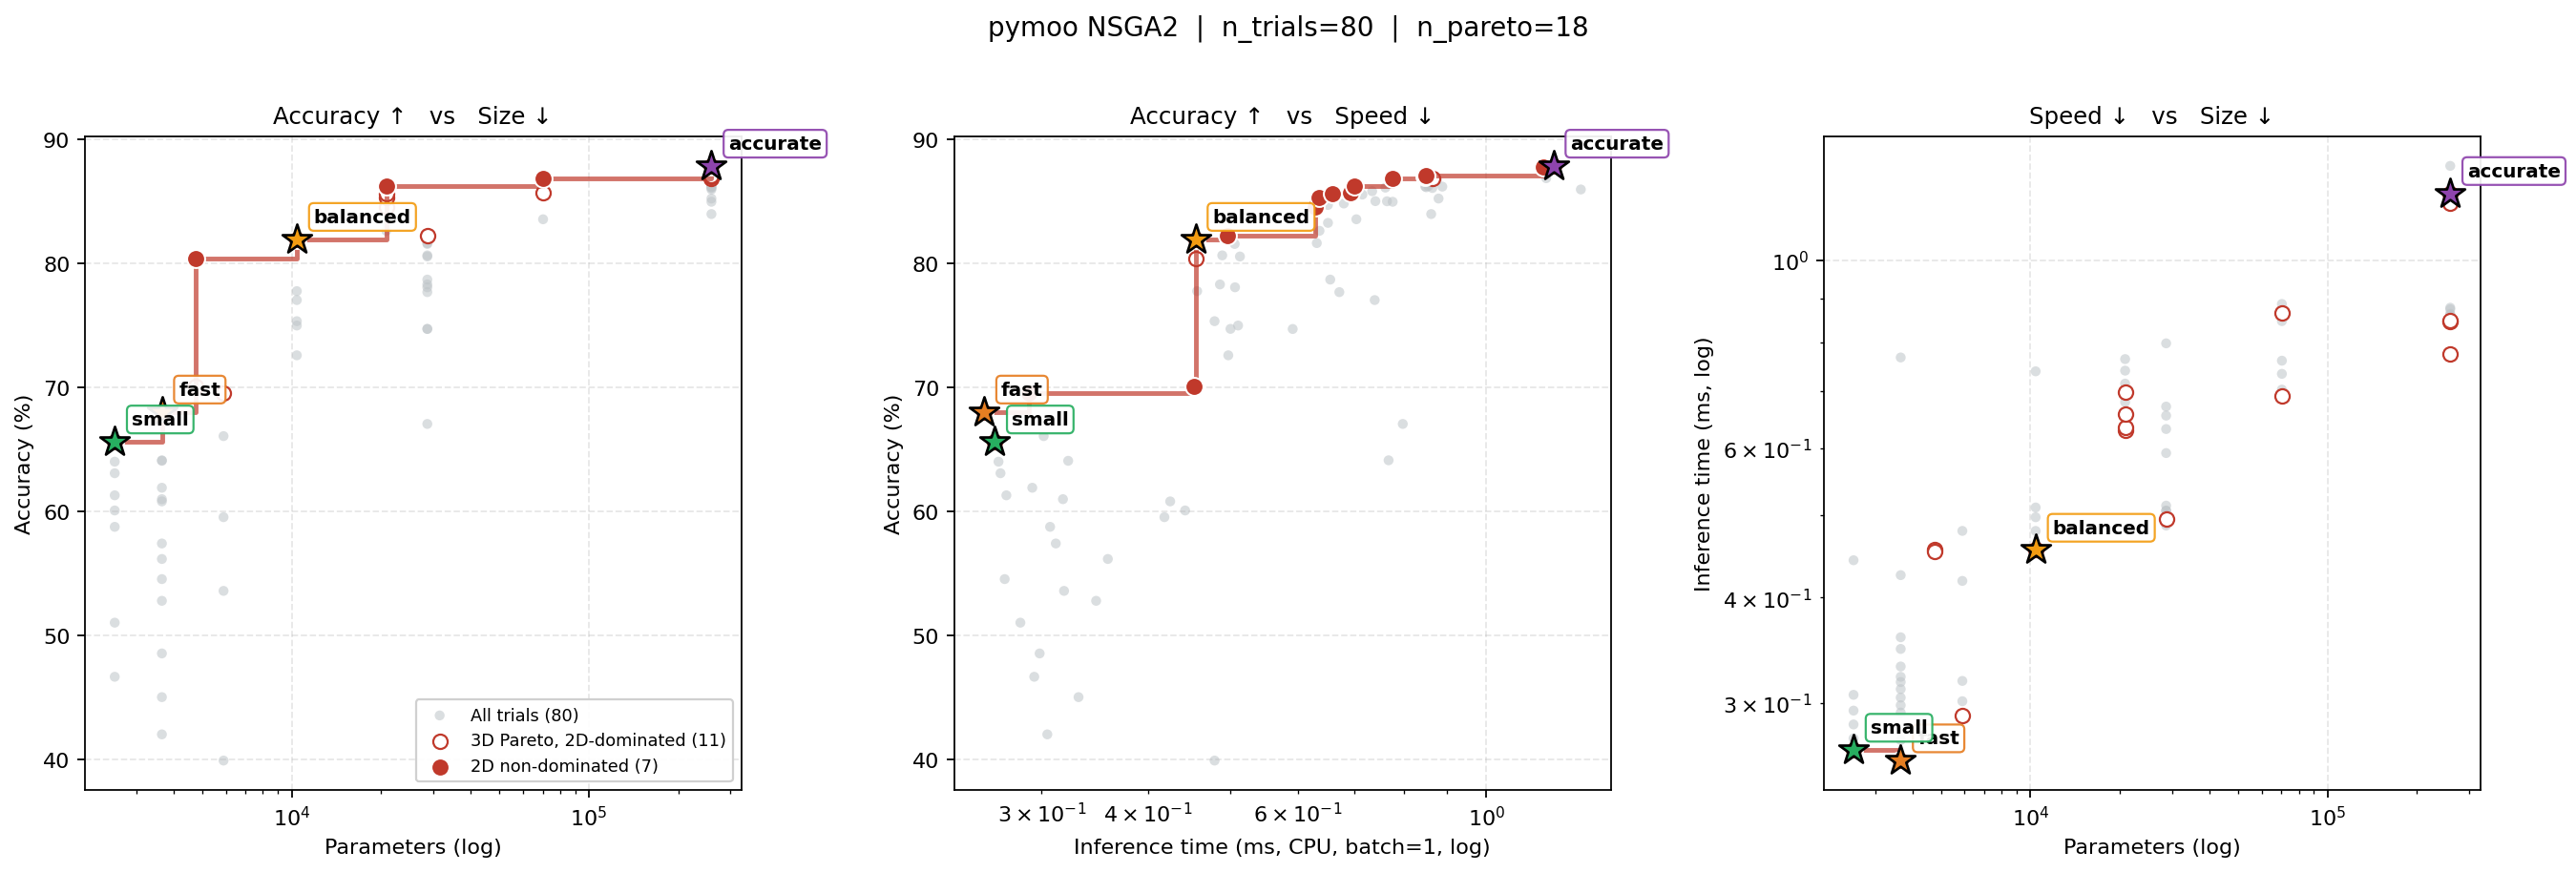

In [6]:
display(Image(filename=str(STUDY_DIR / "plot_2d_panels.png")))

## 7. 2D bubble plot — three objectives in one image

Standard 'three objectives in 2D' visualization: x = inference time, y = accuracy, **marker size + color encode parameter count**. The colorbar maps color → params on a log scale (smaller = lighter / yellower = better).

- A **small light-yellow bubble in the top-left** is the dream solution: fast, accurate, tiny.
- A **big dark bubble in the top-right** is high-accuracy but slow and bloated.
- The Pareto front (black-edged) traces the trade-off frontier — as you walk from bottom-left to top-right, accuracy rises but bubbles get bigger and darker, showing all three objectives moving together.
- **Stars** = the four representative picks. **Diamonds with magenta edge** *(if comparison is enabled)* = other framework's Pareto.

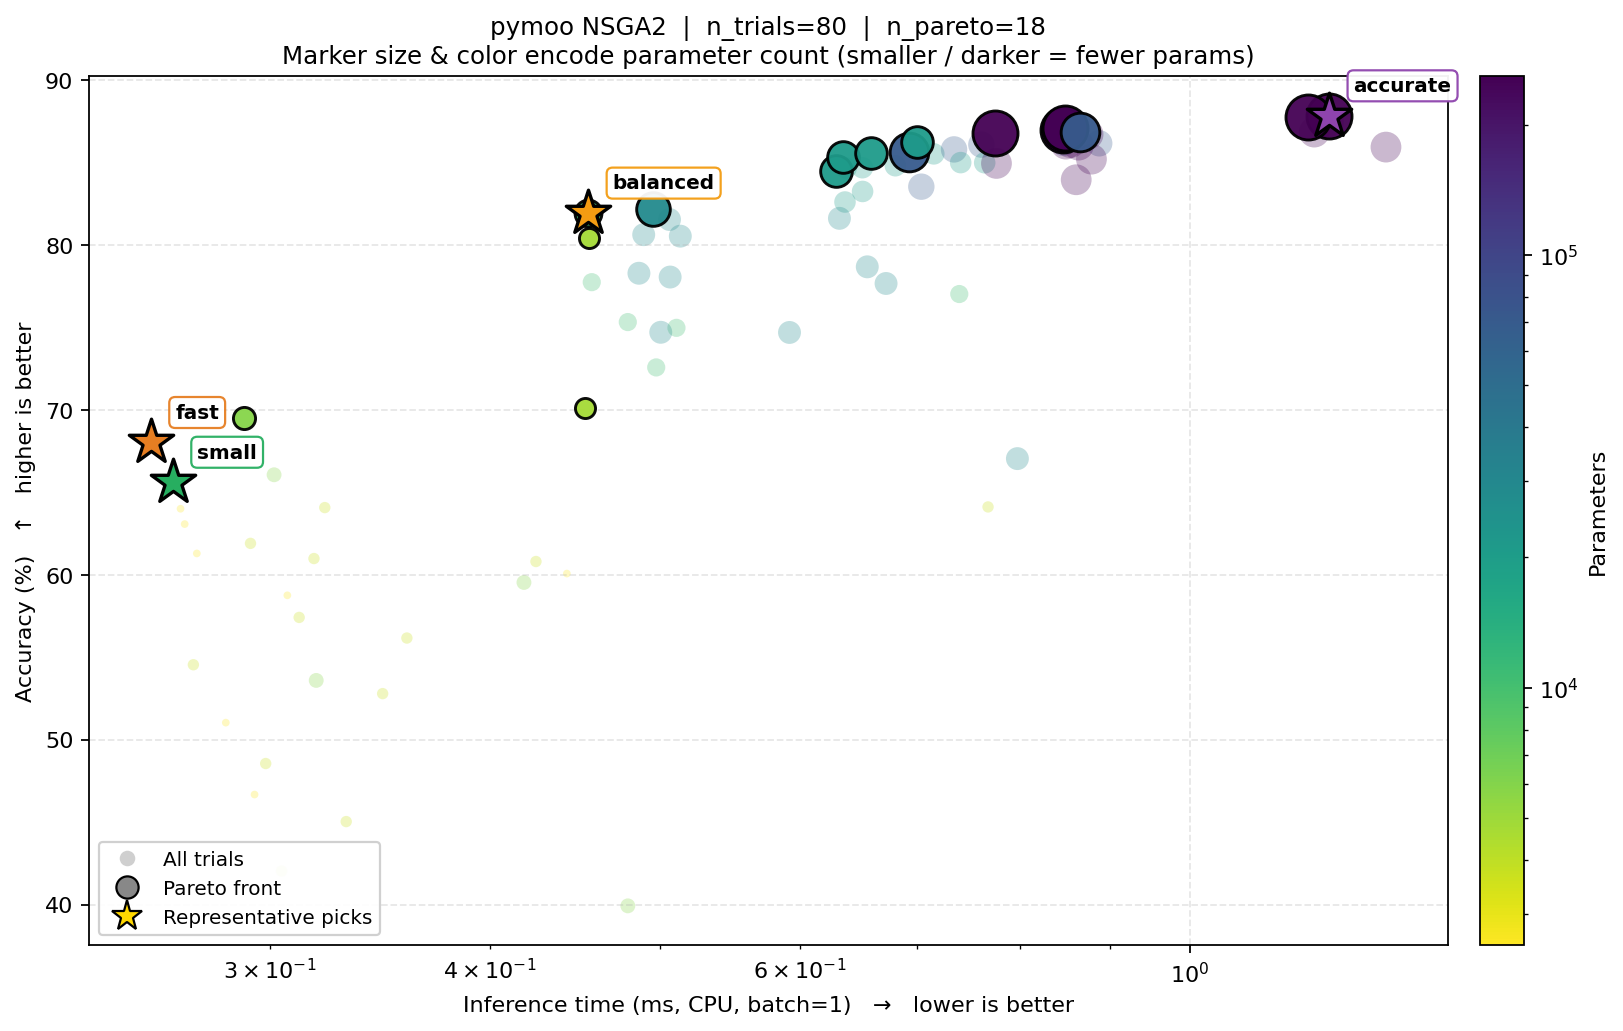

In [8]:
display(Image(filename=str(STUDY_DIR / "plot_3d_scatter.png")))

## 8. 3D Pareto-front scatter

Classic 3D Pareto plot in **all-minimize orientation** (error_rate, inference_ms, params), so the front forms the canonical 'bowl' near the origin — points closer to the corner are better on all three objectives at once. Tick labels are reformatted to physical units (ms, K/M params).

Less useful for precise reading than the 2D plots (depth ambiguity is real on a static 3D image), but it's the canonical way to show 'the front lives in 3D'.

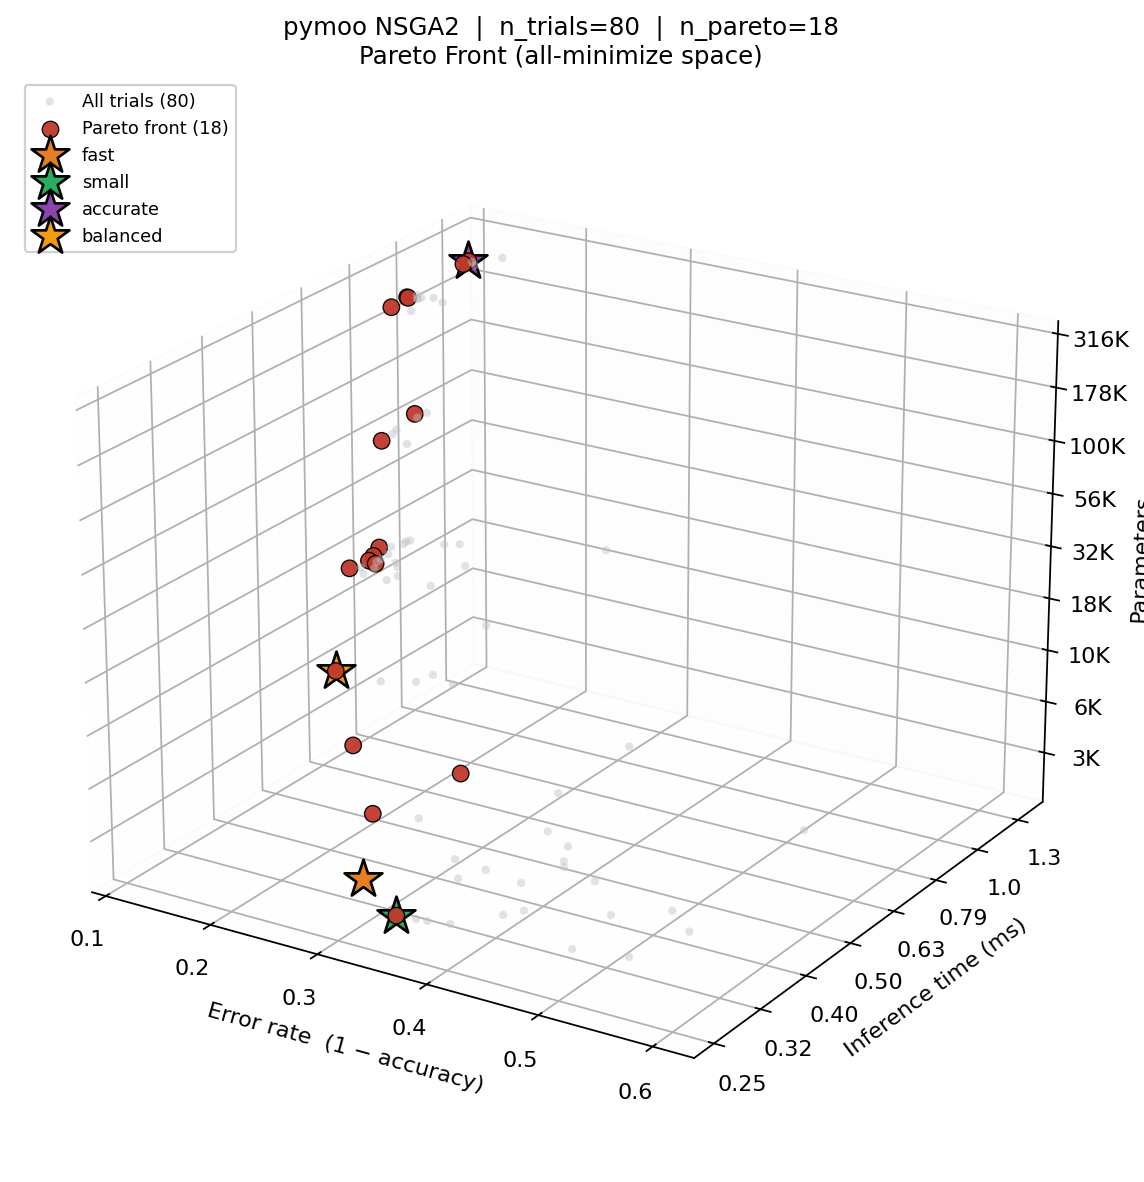

In [9]:
display(Image(filename=str(STUDY_DIR / "plot_3d_pareto.png")))

## 9. Appendix solution — one fully-detailed Pareto-optimal config

The rubric requires *one* fully-specified Pareto-optimal solution in the report appendix. The analyzer picks the **`balanced`** point (closest to the ideal corner in normalized objective space). All hyperparameters that produced this solution are listed below — the report can reproduce it from this config alone.

In [10]:
with (STUDY_DIR / "appendix_solution.json").open() as f:
    appendix = json.load(f)

print(f"Label        : {appendix['label']}")
print(f"Trial number : {appendix.get('trial_number')}")
print()
print("--- Objectives ---")
for k, v in appendix['objectives'].items():
    print(f"  {k:<14s} : {v}")
print()
print("--- Decision variables ---")
for k, v in appendix['decision_variables'].items():
    print(f"  {k:<18s} : {v}")

Label        : balanced (closest-to-ideal Pareto point)
Trial number : 68

--- Objectives ---
  accuracy       : 0.8193
  inference_ms   : 0.454991
  param_count    : 10410

--- Decision variables ---
  arch_type          : plain
  num_conv_layers    : 2
  num_channels       : 16
  num_fc_units       : 128
  learning_rate      : 0.007743887859132244
  batch_size         : 16
  num_epochs         : 8
  dropout_rate       : 0.004859096464726154
  optimizer_type     : SGD
  input_resolution   : 16


## 10. Head-to-head comparison vs the other framework

Auto-finds the most recent **botorch** study for the same dataset, re-runs `analyze` with its Pareto front overlaid on ours, and prints the joint-front metrics — the actual MOO comparison the rubric asks for.

After this runs, all four plot images are *refreshed in place* with the comparison overlay (blue diamonds in 2D and 3D plots). Just re-display them in the cells above to see the comparison.

**What the comparison numbers mean:**
- **Joint Pareto** — the non-dominated set of `(our front ∪ their front)`. The 'true' front you'd get if you ran both frameworks together.
- **Ours surviving / Theirs surviving** — how many of each framework's points actually make it into the joint front. Higher = your framework found genuinely Pareto-optimal points the other missed.
- **GD (generational distance)** — average Euclidean distance from your front to the joint front. Lower = closer to the true front. Compare 'GD ours' vs 'GD other' to see which framework got closer.

In [11]:
candidate = PROJECT_ROOT / "results" / OTHER_FRAMEWORK / DATASET
compare_path = None
if candidate.exists():
    other_runs = sorted([p for p in candidate.iterdir() if p.is_dir()], key=lambda p: p.name)
    if other_runs:
        compare_path = other_runs[-1] / "pareto_front.csv"

if compare_path is None or not compare_path.exists():
    print(f"No {OTHER_FRAMEWORK} run found under {candidate}.")
    print(f"Run {OTHER_FRAMEWORK}_optimization.ipynb first, then re-run this cell.")
else:
    print(f"Comparing against : {compare_path.parent.name}")
    print()
    metrics_cmp = analyze(STUDY_DIR, compare_pareto_path=compare_path)
    if "comparison" in metrics_cmp:
        c = metrics_cmp["comparison"]
        print("--- joint-front analysis ---")
        print(f"joint pareto      : {c['joint_n_pareto']}")
        print(f"ours surviving    : {c['ours_surviving_in_joint']:>3d} / {metrics_cmp['n_pareto_points']}  ({100*c['ours_surviving_in_joint']/max(1,metrics_cmp['n_pareto_points']):.0f}%)")
        print(f"other surviving   : {c['other_surviving_in_joint']:>3d} / {c['compare_n_pareto']}  ({100*c['other_surviving_in_joint']/max(1,c['compare_n_pareto']):.0f}%)")
        print(f"GD ours -> joint  : {c['gd_ours_to_joint']:.6f}  (lower = better)")
        print(f"GD other-> joint  : {c['gd_other_to_joint']:.6f}")
        print()
        winner = "pymoo" if c['gd_ours_to_joint'] < c['gd_other_to_joint'] else OTHER_FRAMEWORK
        print(f"Closer to joint front (lower GD): {winner}")
    print()
    print("Plots have been refreshed with the comparison overlay. Re-display them with the cells above to see the head-to-head visually.")

Comparing against : botorch_qnehvi_fashion_mnist_20260428_094208

--- joint-front analysis ---
joint pareto      : 25
ours surviving    :   6 / 18  (33%)
other surviving   :  19 / 21  (90%)
GD ours -> joint  : 0.066685  (lower = better)
GD other-> joint  : 0.066921

Closer to joint front (lower GD): pymoo

Plots have been refreshed with the comparison overlay. Re-display them with the cells above to see the head-to-head visually.


### Re-display plots with the comparison overlay

Run the cell below after the comparison cell above. Now the plots include the other framework's Pareto for visual head-to-head.

**2D panels with both fronts (red = ours, blue diamonds = comparison)**

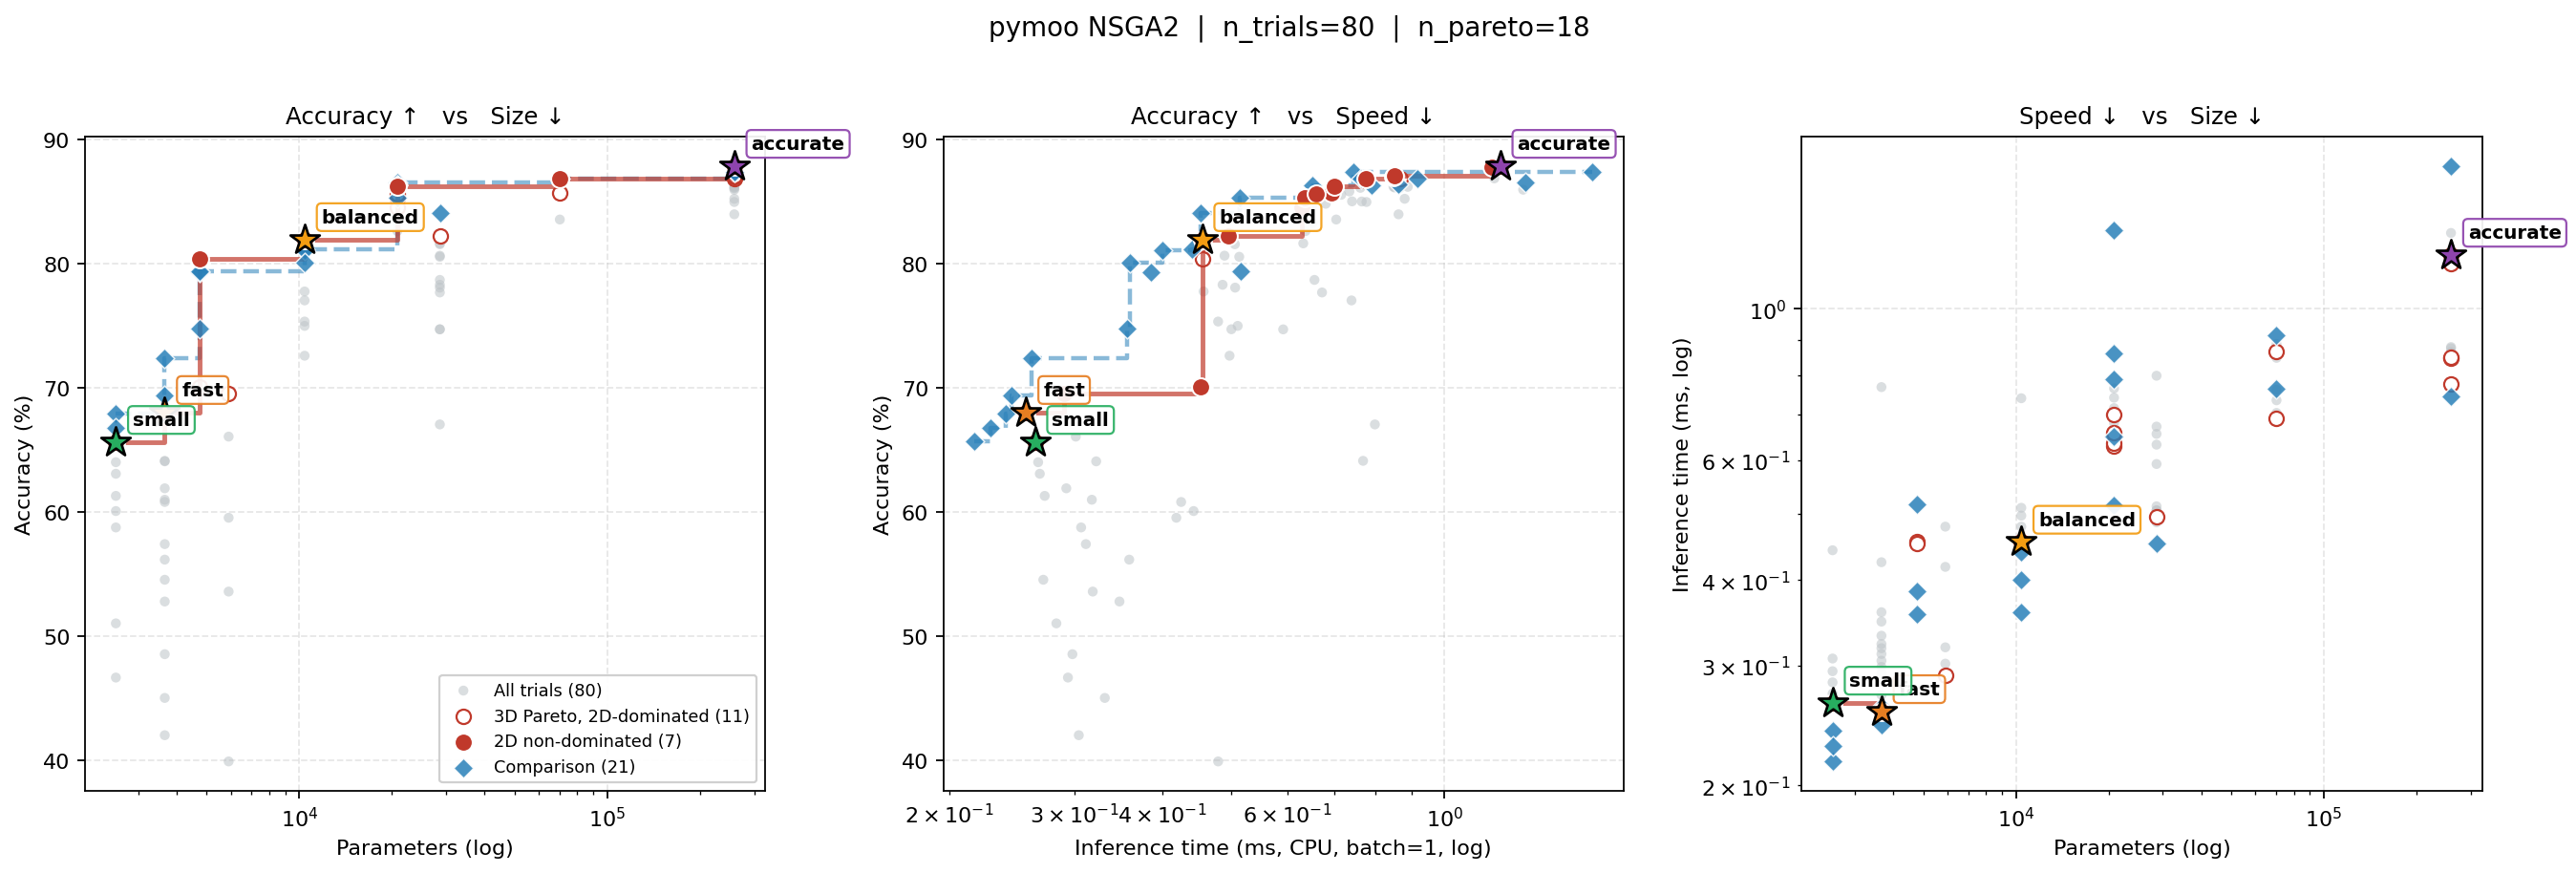

**2D bubble with comparison Pareto (magenta-edged diamonds)**

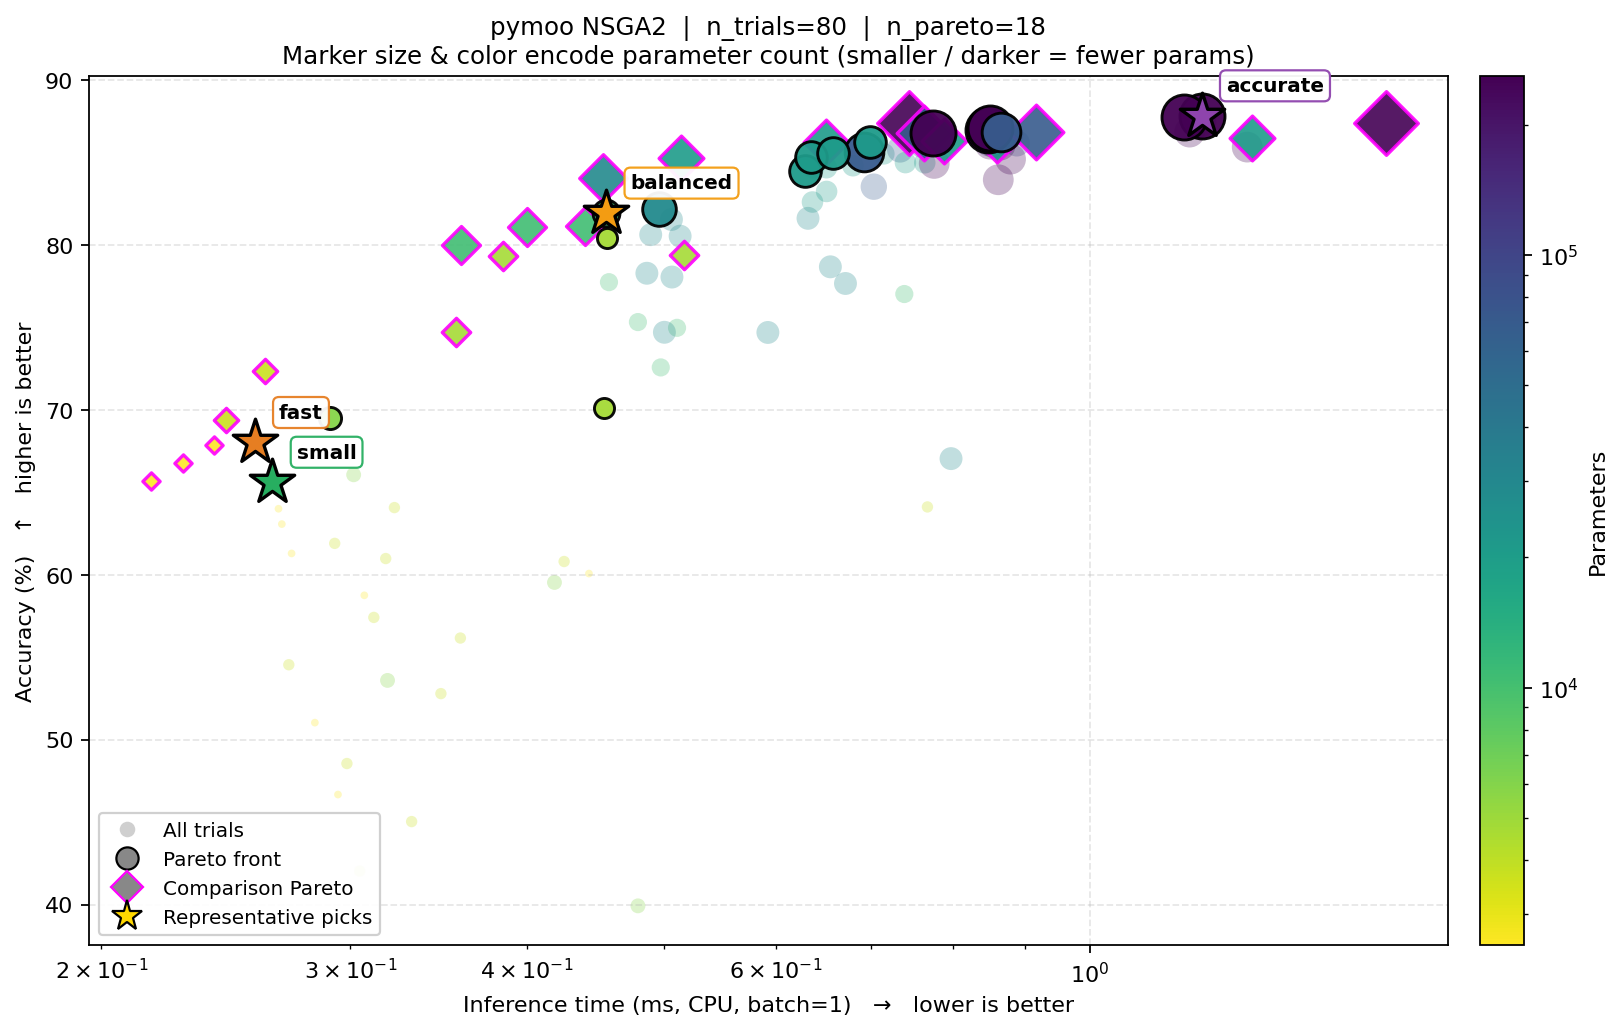

**3D Pareto with comparison overlay (blue diamonds)**

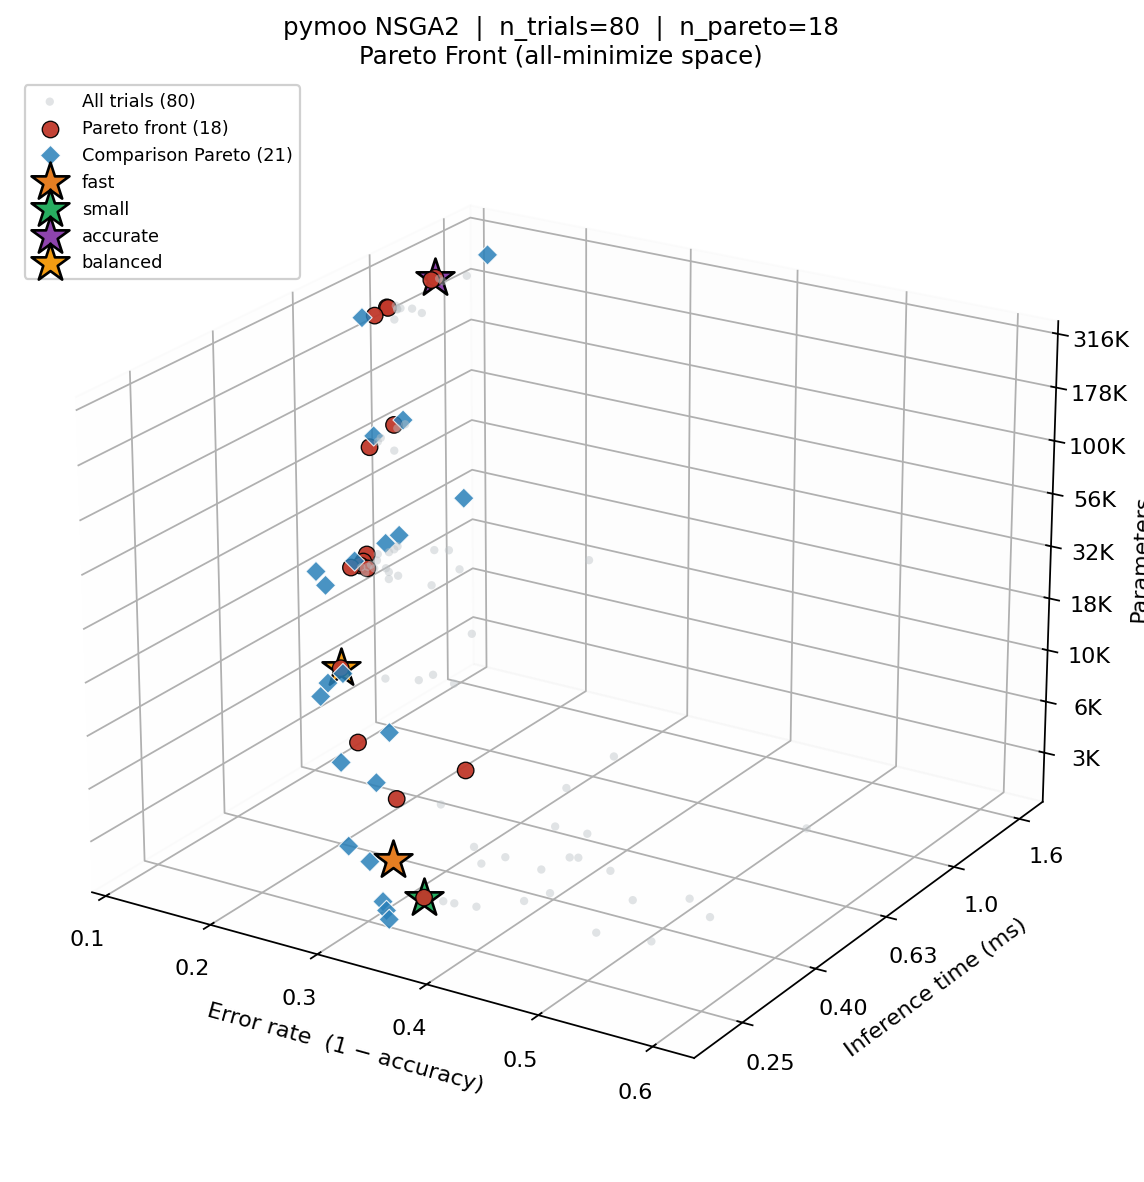

In [12]:
for fname, caption in [
    ("plot_2d_panels.png",       "2D panels with both fronts (red = ours, blue diamonds = comparison)"),
    ("plot_3d_scatter.png",      "2D bubble with comparison Pareto (magenta-edged diamonds)"),
    ("plot_3d_pareto.png",       "3D Pareto with comparison overlay (blue diamonds)"),
]:
    display(Markdown(f"**{caption}**"))
    display(Image(filename=str(STUDY_DIR / fname)))